We enhance an image using three basic gray level transformations:

1. Log Transform
2. Power Law (Gamma) Transform
3. Intensity Level Slicing (Contrast Stretching)

All three work pixel by pixel (point processing), so for every pixel we
just look at its own value and calculate a new value for it - no
neighbours involved (unlike filtering).

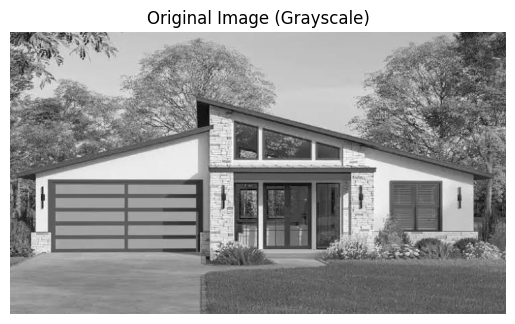

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/content/images.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

height = image_gray.shape[0]
width = image_gray.shape[1]

plt.imshow(image_gray, cmap='gray')
plt.title('Original Image (Grayscale)')
plt.axis('off')
plt.show()

### 1. Log Transform

r must be converted to float before taking log, otherwise numbers
overflow because pixel values are stored as uint8 (0 to 255 only).

after applying log, the values no longer between 0-255,
need to rescale (stretch) them back to the 0-255 range before
displaying / saving the image.

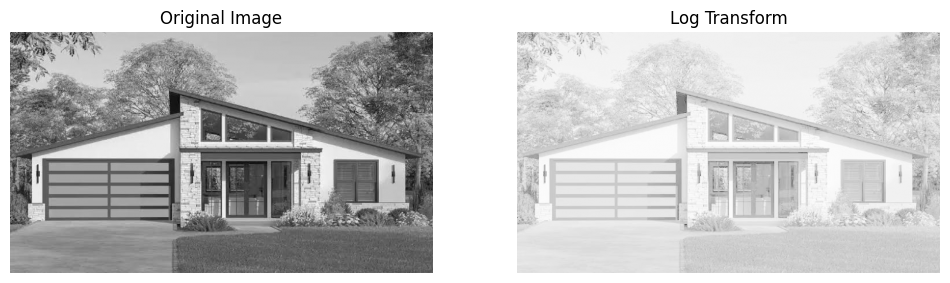

In [2]:
c = 1
log_image = np.zeros((height, width), dtype=np.float32)

for i in range(height):
  for j in range(width):
    pixel = float(image_gray[i][j])
    new_value = c * np.log(1 + pixel)
    log_image[i][j] = new_value

max_val = 0
for i in range(height):
  for j in range(width):
    if log_image[i][j] > max_val:
      max_val = log_image[i][j]

scale = 255 / max_val
for i in range(height):
  for j in range(width):
    log_image[i][j] = log_image[i][j] * scale

log_image = np.clip(log_image, 0, 255)
log_image = log_image.astype(np.uint8)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(log_image, cmap='gray')
plt.title('Log Transform')
plt.axis('off')

plt.show()

### 2. Power Law (Gamma) Transform

Enter the value of gamma (e.g. 0.4 to brighten, 2.5 to darken): 0.4


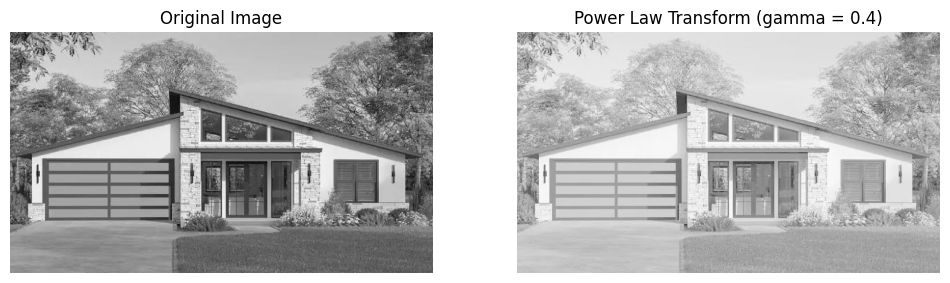

In [3]:
c2 = 1

gamma = float(input("Enter the value of gamma (e.g. 0.4 to brighten, 2.5 to darken): "))

power_image = np.zeros((height, width), dtype=np.float32)

for i in range(height):
  for j in range(width):
    pixel = float(image_gray[i][j]) / 255.0
    new_value = c2 * (pixel ** gamma)
    power_image[i][j] = new_value * 255

power_image = np.clip(power_image, 0, 255)
power_image = power_image.astype(np.uint8)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(power_image, cmap='gray')
plt.title('Power Law Transform (gamma = ' + str(gamma) + ')')
plt.axis('off')

plt.show()

### 3. Intensity Level Slicing

input range of intensity values [in_low, in_high] -> stretch (map) it to a new output range [out_low, out_high].
eg. input range 80 to 120 is stretched to 50 to 150 in the output.

Enter the LOWER input intensity value (e.g. 80): 80
Enter the UPPER input intensity value (e.g. 120): 120
Enter the LOWER output intensity value (e.g. 50): 50
Enter the UPPER output intensity value (e.g. 150): 150


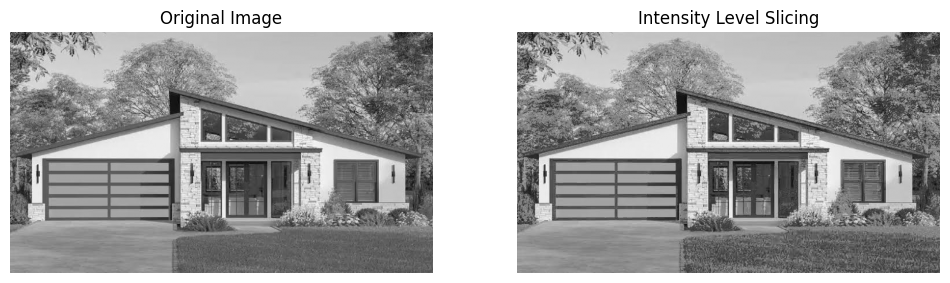

In [4]:
in_low = int(input("Enter the LOWER input intensity value (e.g. 80): "))
in_high = int(input("Enter the UPPER input intensity value (e.g. 120): "))
out_low = int(input("Enter the LOWER output intensity value (e.g. 50): "))
out_high = int(input("Enter the UPPER output intensity value (e.g. 150): "))

slice_image = np.zeros((height, width), dtype=np.uint8)

for i in range(height):
  for j in range(width):
    pixel = int(image_gray[i][j])

    if pixel >= in_low and pixel <= in_high:
      new_value = (pixel - in_low) * (out_high - out_low) / (in_high - in_low) + out_low
      slice_image[i][j] = new_value
    else:
      slice_image[i][j] = pixel

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(slice_image, cmap='gray')
plt.title('Intensity Level Slicing')
plt.axis('off')

plt.show()